# Загрузка данных

Скачаем необходимые библиотеки

In [1]:
!pip install -q catboost datasets optuna sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 11.7 MB/s eta 0:00:00


Импортируем необходимые библиотеки

In [2]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

from torch import cat, cuda, empty, nn, no_grad, sigmoid
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from sentence_transformers import SentenceTransformer

from sklearn.decomposition import PCA
from sklearn.kernel_approximation import RBFSampler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

from optuna import create_study
from optuna.distributions import IntDistribution, FloatDistribution
from optuna.samplers import TPESampler

from catboost import CatBoostRanker, Pool

from tqdm.auto import tqdm
from IPython.display import clear_output

random_state = 42

Загрузим датасет, в котором на каждый вопрос (столбец prompt) даётся 2 ответа и они сравниваются между собой, какой из них релевантнее (столбцы chosen и rejected)

In [3]:
%%time
dataset = load_dataset(
    'HuggingFaceH4/ultrafeedback_binarized',
    split='train_prefs+test_prefs'
)
dataset = dataset.remove_columns([
    'prompt_id',
    'messages',
    'score_chosen',
    'score_rejected'
])

README.md:   0%|          | 0.00/6.53k [00:00<?, ?B/s]

data/train_prefs-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  226MB            

data/train_prefs-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test_prefs-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 7.29MB            

data/test_prefs-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating test_prefs split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test_sft split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating train_gen split:   0%|          | 0/61135 [00:00<?, ? examples/s]

Generating test_gen split:   0%|          | 0/1000 [00:00<?, ? examples/s]

CPU times: user 6.76 s, sys: 2.51 s, total: 9.27 s
Wall time: 30.6 s


Напишем функцию, с помощью которой оставим в соответствующих столбцах только нужный текст

In [4]:
def highlight(example):
    return {
        'prompt': example['prompt'],
        'chosen': example['chosen'][1]['content'],
        'rejected': example['rejected'][1]['content']
    }

Применим функцию

In [5]:
dataset = dataset.map(highlight)

Map:   0%|          | 0/63135 [00:00<?, ? examples/s]

Дальше определим девайс, на котором будут располагаться модели из PyTorch

In [6]:
device = 'cuda' if cuda.is_available() else 'cpu'
device

'cuda'

Загрузим трнасформер, который обучался на задаче парной релевантнонсти на нашем датасете

In [7]:
sentence_transformer = SentenceTransformer('mixedbread-ai/mxbai-embed-large-v1')
sentence_transformer = sentence_transformer.to(device)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/114k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/677 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

Далее напишем функцию, которая по тексту достаёт из модели соответствующий ему эмбеддинг. На этих эмбеддингах в дальнейшем и будут обучаться модели попарного ранжирования

Стоит отметить, что эмбеддинги нормироваться не будут, так как в дальнейшем планируется разделение выборки на тренировочную, валидацонную и тестовую части, а если сейчас провести нормализацию на всей выборке, то это будет утечка данных

In [8]:
def encode(
    response_column,
    prompt_column='prompt',
    batch_size=256,
    normalize_embeddings=False
):
    text = [
        prompt + '; ' + response
        for prompt, response in zip(
            dataset[prompt_column],
            dataset[response_column]
        )
    ]
    return sentence_transformer.encode(
        text,
        batch_size=batch_size,
        show_progress_bar=True,
        normalize_embeddings=normalize_embeddings
    )

Получим эмбеддинги для следующих 2 типов текста:
1) Вопрос + первый ответ
2) Вопрос + второй ответ

In [9]:
%%time
questions_chosen_encoded = encode('chosen')
questions_rejected_encoded = encode('rejected')

Batches:   0%|          | 0/247 [00:00<?, ?it/s]

Batches:   0%|          | 0/247 [00:00<?, ?it/s]

CPU times: user 46min 4s, sys: 3.81 s, total: 46min 8s
Wall time: 45min 5s


Далее разделим выборку на тренировочную, валидационную и тестовую части

In [10]:
def get_data(*data, start_index=0, end_index=len(dataset)):
    return tuple([local_data[start_index:end_index] for local_data in data])

In [11]:
train_index, valid_index = int(len(dataset) * 0.75), int(len(dataset) * 0.875)
questions_chosen_train, questions_rejected_train = get_data(
    questions_chosen_encoded,
    questions_rejected_encoded,
    end_index=train_index
)
questions_chosen_valid, questions_rejected_valid = get_data(
    questions_chosen_encoded,
    questions_rejected_encoded,
    start_index=train_index,
    end_index=valid_index
)
questions_chosen_test, questions_rejected_test = get_data(
    questions_chosen_encoded,
    questions_rejected_encoded,
    start_index=valid_index
)

Размерность эмбеддингов слишком большая - 1024, модели на данных такой размерности будут обучаться очень долго, поэтому было принято решенение с помощью PCA снизить размерность признакового пространства

В нашем случае новая разерность будет равняться 20

In [12]:
n_components = 20

In [13]:
def reduce(train, valid, test, n_components=10, random_state=random_state):
    pca = PCA(n_components=n_components, random_state=random_state)
    pca.fit(train)
    return pca, tuple([pca.transform(local) for local in [train, valid, test]])

In [14]:
%%time
pca_chosen, (
    questions_chosen_train_reduced,
    questions_chosen_valid_reduced,
    questions_chosen_test_reduced
) = reduce(
    questions_chosen_train,
    questions_chosen_valid,
    questions_chosen_test,
    n_components=n_components
)

pca_rejected, (
    questions_rejected_train_reduced,
    questions_rejected_valid_reduced,
    questions_rejected_test_reduced
) = reduce(
    questions_rejected_train,
    questions_rejected_valid,
    questions_rejected_test,
    n_components=n_components
)

CPU times: user 17.4 s, sys: 1.28 s, total: 18.7 s
Wall time: 12 s


Далее для каждого алгоритма PCA можно визуализировать некоторые его статистики

In [15]:
def plot_components_statistics(
    statistics,
    title,
    figsize=(12, 5),
    palette='RdBu',
    fontsize=8,
    fmt='%.3f'
):
    ax = plt.subplots(figsize=figsize)[1]
    sns.barplot(statistics, palette=palette, ax=ax)
    for container in ax.containers:
        ax.bar_label(container, fontsize=fontsize, fmt=fmt)
    plt.suptitle(title)
    plt.show()

/tmp/ipykernel_771/2329625245.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(statistics, palette=palette, ax=ax)


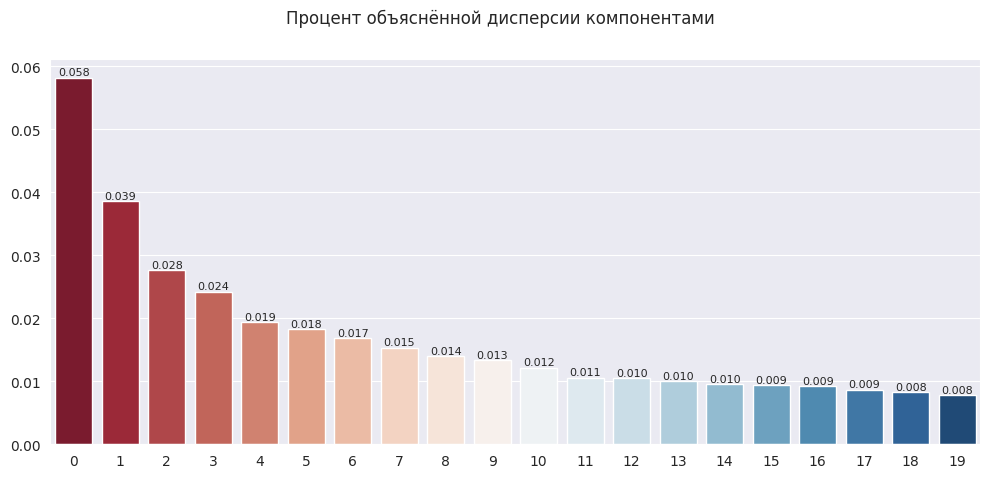

In [16]:
plot_components_statistics(
    pca_chosen.explained_variance_ratio_,
    'Процент объяснённой дисперсии компонентами'
)

/tmp/ipykernel_771/2329625245.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(statistics, palette=palette, ax=ax)


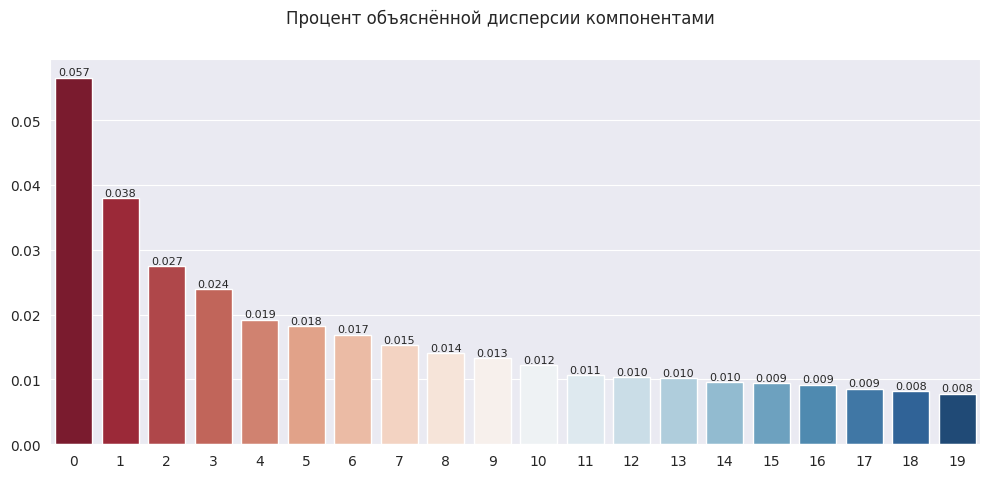

In [17]:
plot_components_statistics(
    pca_rejected.explained_variance_ratio_,
    'Процент объяснённой дисперсии компонентами'
)

/tmp/ipykernel_771/2329625245.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(statistics, palette=palette, ax=ax)


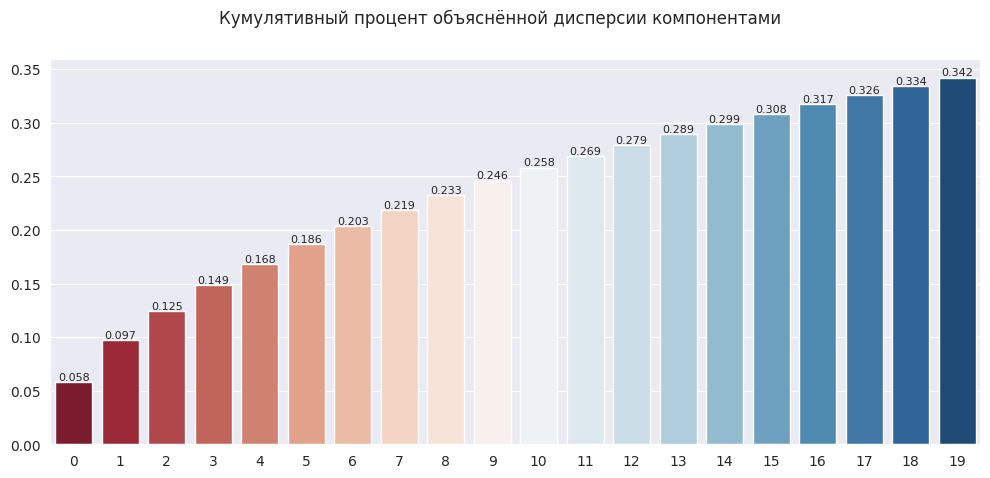

In [18]:
plot_components_statistics(
    np.cumsum(pca_chosen.explained_variance_ratio_),
    'Кумулятивный процент объяснённой дисперсии компонентами'
)

/tmp/ipykernel_771/2329625245.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(statistics, palette=palette, ax=ax)


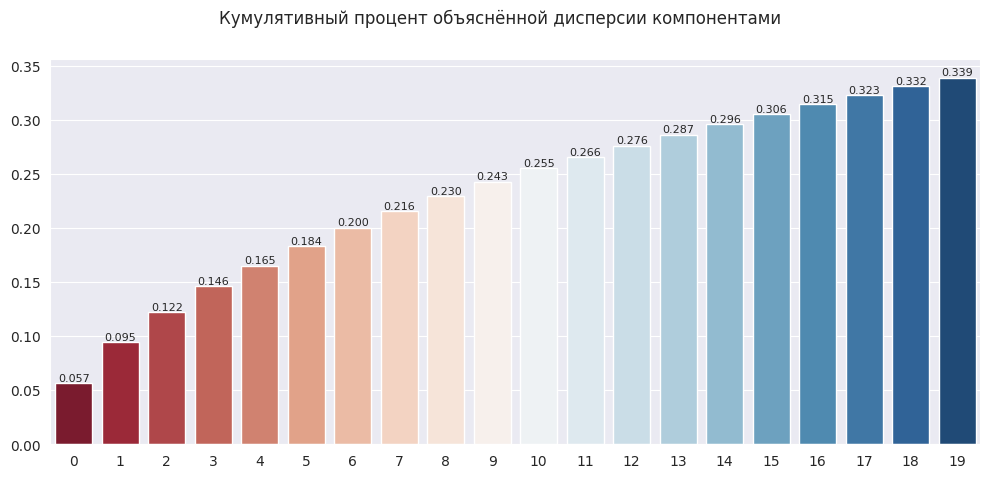

In [19]:
plot_components_statistics(
    np.cumsum(pca_rejected.explained_variance_ratio_),
    'Кумулятивный процент объяснённой дисперсии компонентами'
)

/tmp/ipykernel_771/2329625245.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(statistics, palette=palette, ax=ax)


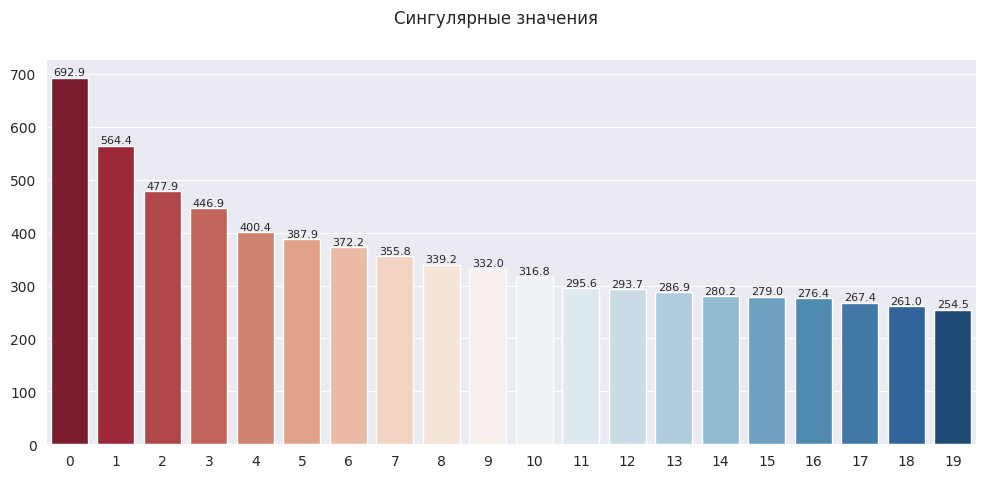

In [20]:
plot_components_statistics(
    pca_chosen.singular_values_,
    'Сингулярные значения',
    fmt='%.1f'
)

/tmp/ipykernel_771/2329625245.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(statistics, palette=palette, ax=ax)


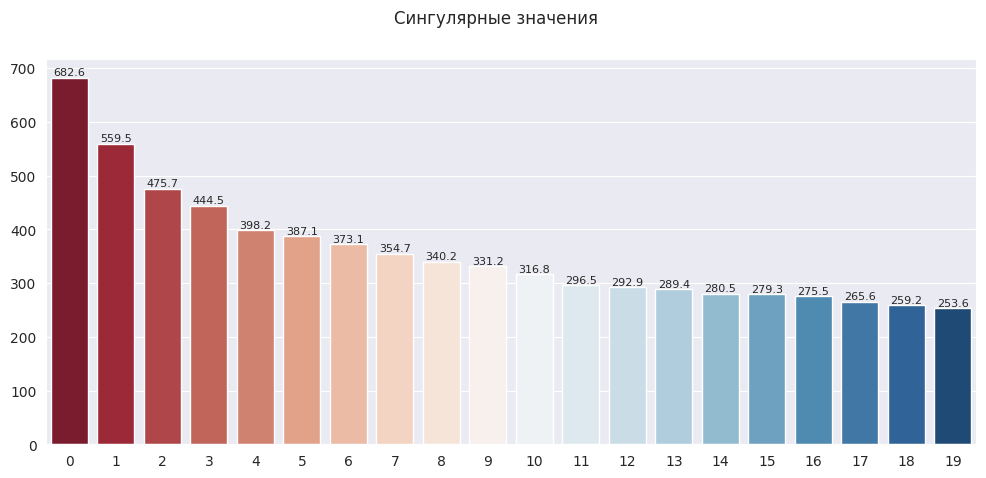

In [21]:
plot_components_statistics(
    pca_rejected.singular_values_,
    'Сингулярные значения',
    fmt='%.1f'
)

Видим, что суммарно алгоритм объясняет примерно треть от исходной дисперсии. С учётом того, что число компонент снизилось более чем в 50 раз, это неплохой результат

Дальше сжатые эмбеддинги надо отнормировать, так как данные будут подаваться на вход линейным моделям и нейронным сетям

In [22]:
def scale(train, valid, test):
    scaler = StandardScaler()
    scaler.fit(train)
    return tuple([scaler.transform(local) for local in [train, valid, test]])

In [23]:
(
    questions_chosen_train_scaled,
    questions_chosen_valid_scaled,
    questions_chosen_test_scaled
) = scale(
    questions_chosen_train_reduced,
    questions_chosen_valid_reduced,
    questions_chosen_test_reduced
)

(
    questions_rejected_train_scaled,
    questions_rejected_valid_scaled,
    questions_rejected_test_scaled
) = scale(
    questions_rejected_train_reduced,
    questions_rejected_valid_reduced,
    questions_rejected_test_reduced
)

## Обучение моделей

Сначала определим датасет, который по индексу бцдет выдавать класс (какой из ответов предпочтительнее, первый или второй), а также сами первый и второй ответы

У нас изначально всегда первые ответы предпочтительнее вторых, поэтому я перемешаю их и теперь релевантность ответов друг относительно друга будет определять поле class

In [24]:
class EmbeddingDataset(Dataset):
    def __init__(self, questions_chosen, questions_rejected):
        super().__init__()
        self.questions_chosen = questions_chosen
        self.questions_rejected = questions_rejected
        self.length = self.questions_chosen.shape[0]
        self.random = np.random.randint(0, 2, self.length).astype(np.float32)

    def __getitem__(self, index):
        batch = {'class': self.random[index]}
        if self.random[index] == 0:
            batch['first'] = self.questions_rejected[index].astype(np.float32)
            batch['second'] = self.questions_chosen[index].astype(np.float32)
        else:
            batch['first'] = self.questions_chosen[index].astype(np.float32)
            batch['second'] = self.questions_rejected[index].astype(np.float32)
        return batch

    def __len__(self):
        return self.length

Получим датасеты для выборок

In [25]:
dataset_train = EmbeddingDataset(
    questions_chosen_train_scaled,
    questions_rejected_train_scaled
)
dataset_valid = EmbeddingDataset(
    questions_chosen_valid_scaled,
    questions_rejected_valid_scaled
)
dataset_test = EmbeddingDataset(
    questions_chosen_test_scaled,
    questions_rejected_test_scaled
)

### Ranking SVM

Правильно подготовим данные для алгоритма RankSVM - выделим отдельно первые и вторые вопросы, а также целевую переменную

In [26]:
def make_svm_datasets(dataset, dimension=n_components):
    first, second, y = (
        np.empty([0, dimension]),
        np.empty([0, dimension]),
        np.empty([0])
    )
    for dictionary in tqdm(dataset):
        first = np.vstack([first, dictionary['first']])
        second = np.vstack([second, dictionary['second']])
        y = np.concatenate([y, np.array([dictionary['class']])])
    return first, second, y

Получим нужные данные для датасетов

In [27]:
first_train, second_train, y_train = make_svm_datasets(dataset_train)
first_valid, second_valid, y_valid = make_svm_datasets(dataset_valid)
first_test, second_test, y_test = make_svm_datasets(dataset_test)

  0%|          | 0/47351 [00:00<?, ?it/s]

  0%|          | 0/7892 [00:00<?, ?it/s]

  0%|          | 0/7892 [00:00<?, ?it/s]

Перейдём к нашей первой модели попарного ранжирования - RankSVM

Сначала рассмотрим линейный случай - если для запроса объект $\large{x_i}$ релевантнее объекта $\large{x_j}$ $\large{(x_i\succ x_j)}$, то линейная модель с весами $\large{w}$ должна присвоить им скоры так, чтобы $\large{w^Tx_i > w^Tx_j}$. Это равенство переписывается как $\large{w^T(x_i-x_j)>0}$

Далее формируется новый вектор признаков $\large{d=x_i-x_j}$ с бинарной меткой $\large{y_{ij}=\pm 1}$ и решается классическая задача SVM:
$$\large{\begin{cases}\underset{w}{\min}\frac{||w||^2}{2}+\sum_{i,j \in P}\xi_{ij} \\ w^T(x_i-x_j) \geq 1 - \xi_{ij} \\ \xi_{ij} > 0\end{cases},}$$
где:
- $\large{P}$ - множество корректных пар

При попытке применить ядерный переход модель сталкивается с вычислительным взрывом из-за перехода к парам, так как в двойственной задаче ядро $\large{K(x_i - x_j, x_k - x_l)}$ должно вычисляться между парами разностей и матрица будет иметь размер $\large{P \times P \sim O(N^4)}$. Также помним, что по времени обучения асимптотика будет $\large{O(N^6)}$ что в нашем случае неподъёмно. Ну и для нелинейного ядра скалярное произведение разности объектов в спрямляющем пространстве не равно разности их образов:
$$\large{K(x_i - x_j) \neq K(x_i) - K(x_j)}$$

Однако разность ядерных отображений в явном виде дает эквивалентный линейный оператор, который можно найти при помощи RBFSampler. По теореме Бохнера RBF-ядро аппроксимируется средним по $\large{D}$ случайным проекциям. Для одиночного вектора $\large{x \in \mathbb{R}^d}$ функция RBFSampler формирует новое явное признаковое описание $\large{z(x) \in \mathbb{R}^D}$:
$$\large{z(x)=\sqrt{\frac{2}{D}}\cdot cos(Wx+B),}$$
где:
- $\large{W \in \mathbb{R}^{D \times d}}$ - случайная матрица, сэмплированная из $\large{\mathcal{N}(0, 2\gamma I)}$
- $\large{B \in \mathbb{R}^D}$ - векторы фазовых сдвигов из $\large{U(0, 2\pi)}$
- $\large{D, d}$ - новая и старая размерности

Благодаря этому скаярное произведение 2 трансформированных объектов приближает нелинейную функцию RBF-ядра:
$$\large{\langle z(x_i), z(x_j)\rangle\approx K_{RBF}(x_i,x_j)=e^{-\gamma||x_i-x_j||^2}}$$

Новый результирующий вектор разности выглядит следующим образом:
$$\large{d'_{ij}=z(x_i)-z(x_j)=\sqrt{\frac{2}{D}}\left[cos(Wx_i+B)-cos(Wx_j+B)\right]}$$

Дальше на новых признаках решается всё та же задача линейного SVM:
$$\large{\begin{cases}\underset{w}{\min}\frac{||w||^2}{2}+\sum_{i,j \in P}\xi_{ij} \\ w^T(z(x_i)-z(x_j)) \geq 1 - \xi_{ij} \\ \xi_{ij} > 0\end{cases},}$$

С RBFSampler все векторы $\large{z(x_i)}$ вычисляются за $\large{O(N\cdot D\cdot d)}$ и при этом по итогу весовой вектор $\large{w \in \mathbb{R}^D}$ выучивает нелинейные разделяющие поверхности исходных данных $\large{x}$

In [28]:
def rbf_transform(
    train,
    valid,
    test,
    n_components=1000,
    random_state=random_state
):
    rbf_sampler = RBFSampler(
        gamma='scale',
        n_components=n_components,
        random_state=random_state
    )
    train_rbf = rbf_sampler.fit_transform(train)
    valid_rbf = rbf_sampler.transform(valid)
    test_rbf = rbf_sampler.transform(test)
    return train_rbf, valid_rbf, test_rbf

Получим новые RBF-данные для первых вопросов

In [29]:
%%time
first_train_rbf, first_valid_rbf, first_test_rbf = rbf_transform(
    first_train,
    first_valid,
    first_test,
)

CPU times: user 2.11 s, sys: 212 ms, total: 2.33 s
Wall time: 1.76 s


А теперь тоже самое для вторых

In [30]:
%%time
second_train_rbf, second_valid_rbf, second_test_rbf = rbf_transform(
    second_train,
    second_valid,
    second_test,
)

CPU times: user 2.16 s, sys: 445 ms, total: 2.61 s
Wall time: 1.91 s


Объявим класс модели RankSVM

In [31]:
class RankSVM:
    def __init__(self, *args, **kwargs):
        self.svc = LinearSVC(*args, **kwargs)

    def fit(self, first, second, y):
        X = first - second
        self.svc.fit(X, y)

    def predict(self, first, second):
        return (
            first @ self.svc.coef_.T > second @ self.svc.coef_.T
        ).ravel().astype(int)

Для модели будут подбираться оптимальные гиперпараметры с помощью Optuna на валидационной выборке, для модели RankSVM это будет делать функция svm_objective

В качестве оптимизируемой метрики будет использоваться обычная accuracy, то есть просто количество правильно отранжированных пар

In [32]:
def svm_objective(trial, **default_params):
    param_distributions = {
        'loss': trial.suggest_categorical('loss', ['hinge', 'squared_hinge']),
        'C': trial.suggest_float('C', 1e-4, 1e3, log=True),
    }
    model = RankSVM(**param_distributions, **default_params)
    model.fit(first_train_rbf, second_train_rbf, y_train)
    valid_preds = model.predict(first_valid_rbf, second_valid_rbf)
    accuracy = accuracy_score(y_valid, valid_preds)
    return accuracy

Функция optimize запускает функцию objective для подбора оптимальных гиперпараметров (здесь это svm_objective) и возвращает обученную модель

In [33]:
def optimize(algorithm, objective, *data, n_trials=10, **default_params):
    study = create_study(
        direction='maximize',
        sampler=TPESampler(seed=random_state),
        study_name=f'Оптимизация алгоритма {algorithm.__name__}',
    )
    study.optimize(
        lambda trial: objective(trial, **default_params),
        n_trials=n_trials
    )
    model = algorithm(**study.best_params, **default_params)
    model.fit(*data)
    return model

Запустим обучение для RankSVM

In [34]:
ranksvm = optimize(
    RankSVM,
    svm_objective,
    first_train_rbf,
    second_train_rbf,
    y_train,
    n_trials=15,
    random_state=random_state
)

[I 2026-08-21 10:42:19,466] A new study created in memory with name: Оптимизация алгоритма RankSVM
[I 2026-08-21 10:42:42,716] Trial 0 finished with value: 0.8906487582361885 and parameters: {'loss': 'squared_hinge', 'C': 13.3032451015229}. Best is trial 0 with value: 0.8906487582361885.
[I 2026-08-21 10:42:44,052] Trial 1 finished with value: 0.7212366953877344 and parameters: {'loss': 'hinge', 'C': 0.0012358382772306934}. Best is trial 0 with value: 0.8906487582361885.
[I 2026-08-21 10:43:04,313] Trial 2 finished with value: 0.8920425747592499 and parameters: {'loss': 'squared_hinge', 'C': 1.6136341713591311}. Best is trial 2 with value: 0.8920425747592499.
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
[I 2026-08-21 10:44:48,171] Trial 3 finished with value: 0.8876077040040548 and parameters: {'loss': 'hinge', 'C': 615.6997328235198}. Best is trial 2 with value: 

Напишем функцию для подсчёта метрик accuracy, precision и recall

In [35]:
def get_report(y_true, y_pred):
    return pd.DataFrame(
        classification_report(y_true, y_pred, output_dict=True)
    )

Итак, получим предсказания и посчитаем метрики

In [36]:
svm_test_preds = ranksvm.predict(first_test_rbf, second_test_rbf)
get_report(y_test, svm_test_preds)

,0.0,1.0,accuracy,macro avg,weighted avg
precision,0.880768,0.893896,0.887228,0.887332,0.887337
recall,0.895511,0.878957,0.887228,0.887234,0.887228
f1-score,0.888078,0.886364,0.887228,0.887221,0.887220
support,3943.000000,3949.000000,0.887228,7892.000000,7892.000000


Итак, видно, что precision и recall примерно равны accuracy, то есть модель одинаково редко ошибается как в сторону нулевого, так и в сторону первого класса

### RankNet

Из наших датасетов получим удобные загрузчики данных (даталоадеры) с размером батча 1024 и перемешиванием данных

In [37]:
train_dataloader = DataLoader(dataset_train, batch_size=1024, shuffle=True)
valid_dataloader = DataLoader(dataset_valid, batch_size=1024, shuffle=True)
test_dataloader = DataLoader(dataset_test, batch_size=1024, shuffle=True)

С точки зрения архитектуры у RankNet всё достаточно просто по сравнению с RankSVM - есть некая нейронная полносвязная сеть $\large{s}$, которая для каждого объекта $\large{x}$ выдаёь некий скор $\large{s(x)}$. Далее - вероятность того, что объект $\large{x_i}$ окажется релевантнее объекта $\large{x_j}$ вычисляется следующим образом:
$$\large{P(x_i \succ x_j)=\sigma\left(s(x_i)-s(x_j)\right)=\frac{1}{1+e^{s(x_j)-s(x_i)}}}$$

При этом целевая переменная $\large{y}$ имеет следующий вид:
$$\large{y=\begin{cases}0, если \ x_j \succ x_i \\ 1, если \ x_i \succ x_j \end{cases}}$$

Функция потерь - обычная бинарная кросс-энтропия:
$$\large{\mathcal{L}=-\sum_{i=1}^n y_i\cdot\log P + (1-y_i)\cdot\log(1-P)}$$

Стоит заметить, что абсолютные значения $\large{s(x)}$ не важны, важен только правильный порядок пары

Итак, объявим класс модели

In [38]:
class RankNet(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.score_function = nn.Sequential(
            nn.Linear(in_features=in_features, out_features=64),
            nn.LeakyReLU(),
            nn.Linear(in_features=64, out_features=128),
            nn.LeakyReLU(),
            nn.Linear(in_features=128, out_features=256),
            nn.LeakyReLU(),
            nn.Linear(in_features=256, out_features=128),
            nn.LeakyReLU(),
            nn.Linear(in_features=128, out_features=64),
            nn.LeakyReLU(),
            nn.Linear(in_features=64, out_features=1)
        )

    def forward(self, question_answer1, question_answer2):
        s1 = self.score_function(question_answer1)[:, 0]
        s2 = self.score_function(question_answer2)[:, 0]
        probs = sigmoid(s1 - s2)
        return probs

    def fit(
        self,
        train_dataloader,
        valid_dataloader,
        num_epochs,
        **optimizer_kwargs
    ):
        device = next(self.parameters()).device
        optimizer = AdamW(self.parameters(), **optimizer_kwargs)
        criterion = nn.BCELoss()
        train_losses, valid_losses = [], []
        train_accuracy, valid_accuracy = [], []
        for epoch in range(1, num_epochs + 1):
            print(f'Тренировка на эпохе номер {epoch}...')
            local_loss, local_accuracy = 0, 0
            for batch in tqdm(train_dataloader):
                for key in batch.keys():
                    batch[key] = batch[key].to(device)
                optimizer.zero_grad()
                batch_probs = self.forward(batch['first'], batch['second'])
                batch_preds = (batch_probs > 0.5).to(int)
                loss = criterion(batch_probs, batch['class'])
                local_loss += loss.item()
                local_accuracy += (
                    (batch_preds == batch['class']).sum().item() / \
                    batch['class'].shape[0]
                )
                loss.backward()
                optimizer.step()
            train_losses.append(local_loss / len(train_dataloader))
            train_accuracy.append(local_accuracy / len(train_dataloader))

            self.eval()
            with no_grad():
                print(f'Валидация на эпохе номер {epoch}...')
                local_loss, local_accuracy = 0, 0
                for batch in tqdm(valid_dataloader):
                    for key in batch.keys():
                        batch[key] = batch[key].to(device)
                    batch_probs = self.forward(batch['first'], batch['second'])
                    batch_preds = (batch_probs > 0.5).to(int)
                    loss = criterion(batch_probs, batch['class'])
                    local_loss += loss.item()
                    local_accuracy += (
                        (batch_preds == batch['class']).sum().item() / \
                        batch['class'].shape[0]
                    )
                valid_losses.append(local_loss / len(valid_dataloader))
                valid_accuracy.append(local_accuracy / len(valid_dataloader))
            self.train()

            clear_output(wait=True)

            axis = plt.subplots(ncols=2, figsize=(12, 6))[1]
            axis[0].plot(
                range(1, epoch + 1),
                train_losses,
                color='blue',
                label='Train'
            )
            axis[0].plot(
                range(1, epoch + 1),
                valid_losses,
                color='orange',
                label='Valid'
            )
            axis[0].set_title('Loss')
            axis[1].plot(
                range(1, epoch + 1),
                train_accuracy,
                color='blue',
                label='Train'
            )
            axis[1].plot(
                range(1, epoch + 1),
                valid_accuracy,
                color='orange',
                label='Valid'
            )
            axis[1].set_title('Accuracy')
            for ax in axis:
                ax.legend()
            plt.show()

    def predict(self, test_dataloader):
        device = next(self.parameters()).device
        self.eval()
        preds, real = empty([0]), empty([0])
        with no_grad():
            print('Предсказание для тестовой выборки...')
            for batch in tqdm(test_dataloader):
                for key in batch.keys():
                    batch[key] = batch[key].to(device)
                batch_probs = self.forward(batch['first'], batch['second'])
                batch_preds = (batch_probs > 0.5).to(int)
                preds = cat([preds, batch_preds.cpu()])
                real = cat([real, batch['class'].cpu()])
        self.train()
        return preds, real

Запустим обучение RankNet

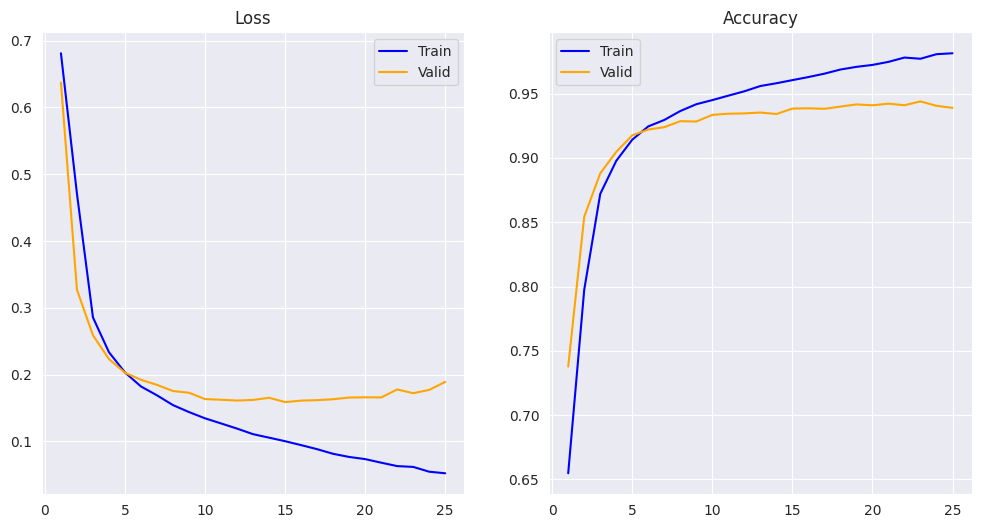

In [39]:
ranknet = RankNet(n_components).to(device)
ranknet.fit(train_dataloader, valid_dataloader, 25, lr=3e-4)

Получим предсказания и посчитаем метрики

In [40]:
ranknet_preds, real_test = ranknet.predict(test_dataloader)
get_report(real_test, ranknet_preds)

Предсказание для тестовой выборки...


  0%|          | 0/8 [00:00<?, ?it/s]

,0.0,1.0,accuracy,macro avg,weighted avg
precision,0.938543,0.941087,0.939812,0.939815,0.939816
recall,0.941162,0.938465,0.939812,0.939813,0.939812
f1-score,0.939851,0.939774,0.939812,0.939812,0.939812
support,3943.000000,3949.000000,0.939812,7892.000000,7892.000000


Видим, что метрики заметно подросли по сравнению с RankSVM, однако ситуация с равными долями ошибок в сторону классов осталась

### CatBoostRanker

Отличие CatBoostRanker от RankNet заключается в том, что теперь скор $\large{s}$ вычисляется ансамблем деревьев, а не многослойной нейронной сетью

Функция потерь, называемая PairLogit, выглядит следующим образом:
$$\large{\mathcal{L}_{PairLogit}=\sum_{i,j \in P}ln(1 + e^{s(x_j)-s(x_i)})}$$

Вдаваться в детали работы самого градиентного бустинга я здесь не буду

Теперь подготовим данные правильно для CatBoostRanker, здесь должно быть 3 составляющие:
1. Каждому ответу сопоставляется отдельная строка
2. Каждому ответу сопоставляется группа. Так как на каждый вопрос приходится только 2 ответа, то размер каждой группы будет равен 2
3. Пары, то есть для каждой группы нужно указать индексы отранжированных пар в исходном датасете. Первый элемент пары - индекс более релевантного ответа, а второй - менее релевантнго

In [41]:
def make_catboost_datasets(dataset, dimension=n_components):
    data, groups, pairs = np.empty([0, dimension]), [], []
    for index, dictionary in tqdm(enumerate(dataset)):
        data = np.vstack([data, dictionary['first'], dictionary['second']])
        groups.extend([index, index])
        pairs.extend([[
            index * 2 + 1 - int(dictionary['class'].item()),
            index * 2 + int(dictionary['class'].item())
        ]])
    return data, groups, pairs

Получим нужные данные

In [42]:
%%time
train_data, train_groups, train_pairs = make_catboost_datasets(dataset_train)
valid_data, valid_groups, valid_pairs = make_catboost_datasets(dataset_valid)
test_data, test_groups, test_pairs = make_catboost_datasets(dataset_test)

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

CPU times: user 35.8 s, sys: 335 ms, total: 36.1 s
Wall time: 36.4 s


Объявим класс модели, отнаследованный от CatBoostRanker

In [43]:
class CatBoostRank(CatBoostRanker):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def fit(self, data, group_id, pairs):
        pool = Pool(data=data, group_id=group_id, pairs=pairs)
        super().fit(pool)

    def predict(self, data):
        scores, preds = super().predict(data), []
        for i in range(scores.shape[0] // 2):
            preds.append(int(scores[i * 2] > scores[i * 2 + 1]))
        return preds

Теперь объявим функцию для подбора оптимальных гиперпараметров для модели catboost

In [44]:
def catboost_objective(trial, **default_params):
    param_distributions = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 1000, step=100),
        'depth': trial.suggest_int('depth', 2, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 1, step=1e-3),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 1, step=1e-3),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 50)
    }
    model = CatBoostRank(**param_distributions, **default_params)
    model.fit(train_data, train_groups, train_pairs)
    valid_preds = model.predict(valid_data)
    accuracy = accuracy_score(y_valid, valid_preds)
    return accuracy

Запустим обучение модели CatBoostRank

In [45]:
catboost_rank = optimize(
    CatBoostRank,
    catboost_objective,
    train_data,
    train_groups,
    train_pairs,
    n_trials=10,
    loss_function='PairLogit',
    random_seed=random_state,
    bootstrap_type='No',
    task_type='CPU' if device == 'cpu' else 'GPU',
    verbose=False
)

[I 2026-08-21 10:49:46,641] A new study created in memory with name: Оптимизация алгоритма CatBoostRank
[I 2026-08-21 10:49:54,343] Trial 0 finished with value: 0.9396857577293461 and parameters: {'n_estimators': 700, 'depth': 8, 'l2_leaf_reg': 0.732, 'learning_rate': 0.599, 'min_data_in_leaf': 8}. Best is trial 0 with value: 0.9396857577293461.
[I 2026-08-21 10:49:56,338] Trial 1 finished with value: 0.7821844906234161 and parameters: {'n_estimators': 500, 'depth': 2, 'l2_leaf_reg': 0.867, 'learning_rate': 0.602, 'min_data_in_leaf': 36}. Best is trial 0 with value: 0.9396857577293461.
[I 2026-08-21 10:50:02,746] Trial 2 finished with value: 0.9450076026355804 and parameters: {'n_estimators': 500, 'depth': 8, 'l2_leaf_reg': 0.8330000000000001, 'learning_rate': 0.213, 'min_data_in_leaf': 10}. Best is trial 2 with value: 0.9450076026355804.
[I 2026-08-21 10:50:05,422] Trial 3 finished with value: 0.919158641662443 and parameters: {'n_estimators': 600, 'depth': 4, 'l2_leaf_reg': 0.525, 'l

In [46]:
catboost_test_preds = catboost_rank.predict(test_data)
get_report(y_test, catboost_test_preds)

,0.0,1.0,accuracy,macro avg,weighted avg
precision,0.937422,0.949192,0.943234,0.943307,0.943311
recall,0.949784,0.936693,0.943234,0.943239,0.943234
f1-score,0.943563,0.942901,0.943234,0.943232,0.943231
support,3943.000000,3949.000000,0.943234,7892.000000,7892.000000


Здесь метрики получились ещё выше, чем у RankNet, однако ситуация с распределением ошибок по классам сохраняется

# Выводы

В данной работе использовались 3 различных модели - RankSVM, RankNet и CatBoostRanker

Каждая из моделей достигла значения в 0.88 по метрике accuracy, и при этом ошибки одинаково распределены в стороны классов